Part 1
Slope: 0.9500, Intercept: 0.5900, R^2: 0.9671


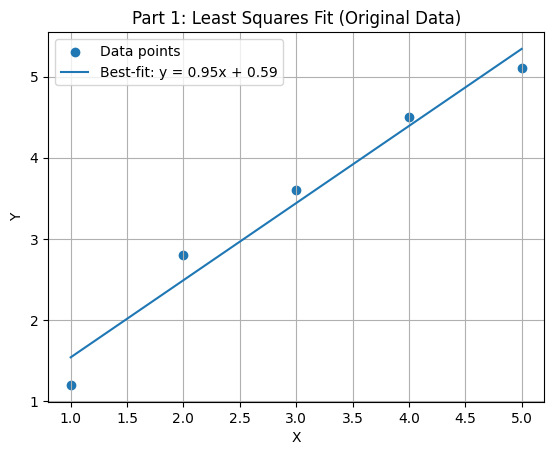


Part 2
Randomized Y: [3.6 5.1 4.5 1.2 2.8]
Slope: -0.5500, Intercept: 5.0900, R^2: 0.3242


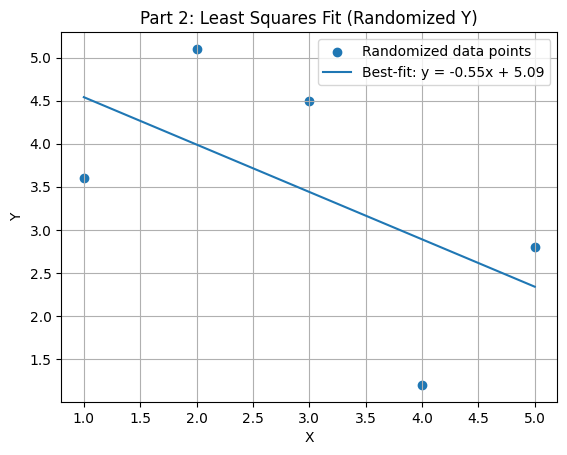


Part 3
True line:     y = 2.3000x + -0.7000
Recovered fit: y = 2.3079x + -0.7001
R^2: 0.9949


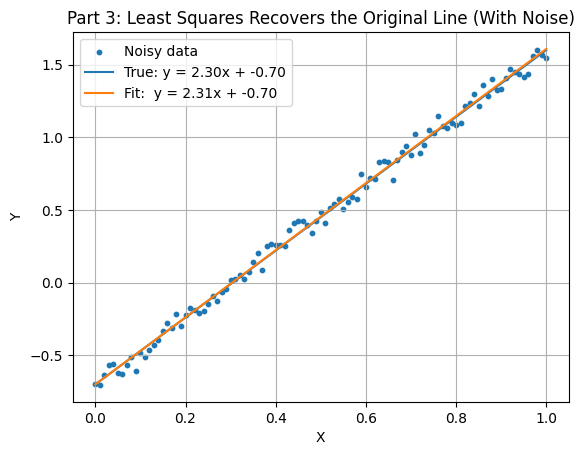

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def least_squares_line(x, y):
    # Returns slope m and intercept c for y = m x + c using least squares
    A = np.vstack([x, np.ones(len(x))]).T         # Build the design matrix [x  1] for the linear model
    m, c = np.linalg.lstsq(A, y, rcond=None)[0]   # Solve Ax ≈ y using least squares to get slope and intercept
    return m, c

def r2_score(y, yhat):
    # Compute R^2 to describe how well the line fits the data
    ss_res = np.sum((y - yhat) ** 2)              # Difference between data and fit
    ss_tot = np.sum((y - np.mean(y)) ** 2)        # Total variation of the data around its mean
    return 1 - ss_res / ss_tot                    # R^2 value describing quality of the fit


# Part 1: given data
# -----------------------
X = np.array([1, 2, 3, 4, 5], dtype=float)       # X data points
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1], dtype=float)  # Corresponding Y data values

m1, c1 = least_squares_line(X, Y)                # Compute slope and intercept using least squares
Yhat1 = m1 * X + c1                              # Predicted Y values from the best-fit line

print("Part 1")
print(f"Slope: {m1:.4f}, Intercept: {c1:.4f}, R^2: {r2_score(Y, Yhat1):.4f}")  # Display results

# Plot original data + fit
plt.figure()
plt.scatter(X, Y, label="Data points")            # Plot the raw data points
plt.plot(X, Yhat1, label=f"Best-fit: y = {m1:.2f}x + {c1:.2f}")  # Plot the least-squares line
plt.title("Part 1: Least Squares Fit (Original Data)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()


# Part 2: randomize and rerun
# -----------------------
rng = np.random.default_rng(0)                    # Create a random number generator
Y_rand = rng.permutation(Y)                       # Shuffle Y values to break the linear relationship

m2, c2 = least_squares_line(X, Y_rand)            # Recompute least squares with randomized data
Yhat2 = m2 * X + c2                               # Predicted values from the new best-fit line

print("\nPart 2")
print(f"Randomized Y: {Y_rand}")                  # Show the shuffled Y values
print(f"Slope: {m2:.4f}, Intercept: {c2:.4f}, R^2: {r2_score(Y_rand, Yhat2):.4f}")  # Display fit results

# Plot randomized data + fit
plt.figure()                                      # Create another figure window
plt.scatter(X, Y_rand, label="Randomized data points")  # Plot shuffled data
plt.plot(X, Yhat2, label=f"Best-fit: y = {m2:.2f}x + {c2:.2f}")  # Plot best-fit line for randomized data
plt.title("Part 2: Least Squares Fit (Randomized Y)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

# Explanation:
# After randomizing, the points no longer follow a clean linear trend,
# so the best-fit line typically fits worse (lower R^2).


# Part 3: make your own line + noise
# -----------------------
m_true = 2.3                                      # True slope of the line we generate
c_true = -0.7                                     # True intercept

X3 = np.arange(0, 1.01, 0.01)                     # Generate x values from 0 to 1 in steps of 0.01
noise = rng.normal(0, 0.05, size=X3.shape)        # Generate small random noise to simulate measurement error
Y3 = m_true * X3 + c_true + noise                 # Compute y values using the true line plus noise

m3, c3 = least_squares_line(X3, Y3)               # Estimate slope and intercept from the noisy data
Yhat3 = m3 * X3 + c3                              # Predicted values using the estimated best-fit line

print("\nPart 3")
print(f"True line:     y = {m_true:.4f}x + {c_true:.4f}")  # Show the actual line used to generate data
print(f"Recovered fit: y = {m3:.4f}x + {c3:.4f}")          # Show the line found by least squares
print(f"R^2: {r2_score(Y3, Yhat3):.4f}")                   # Display goodness of fit

# Plot noisy data + true line + recovered best-fit
plt.figure()                                              # Create another figure
plt.scatter(X3, Y3, s=10, label="Noisy data")             # Plot generated noisy data points
plt.plot(X3, m_true * X3 + c_true, label=f"True: y = {m_true:.2f}x + {c_true:.2f}")  # Plot true underlying line
plt.plot(X3, Yhat3, label=f"Fit:  y = {m3:.2f}x + {c3:.2f}")  # Plot recovered least-squares line
plt.title("Part 3: Least Squares Recovers the Original Line (With Noise)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()